In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/insurance.csv')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


**TASK1:**
As anyone can notice, the dataset insurance.csv contains 3 categorical columns which describe the gender(sex),if each person in this dataset smokes or not(smoker) and their regions(region). The rest 4 columns are numerical(integers &floats) and desrcribe age, bmi, how many children does each one have and the cost(charges). The total rows presented are 1338 of which no one has null value.


In [8]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [15]:
numerical_columns = df[['age','bmi','children','charges']]

print("Mean of each column:",numerical_columns.mean())
print("Median of each column:",numerical_columns.median())
print("Standard Deviation of each column:",numerical_columns.std())
print("Mode of each column:",numerical_columns.mode())


Mean of each column: age            39.207025
bmi            30.663397
children        1.094918
charges     13270.422265
dtype: float64
Median of each column: age           39.000
bmi           30.400
children       1.000
charges     9382.033
dtype: float64
Standard Deviation of each column: age            14.049960
bmi             6.098187
children        1.205493
charges     12110.011237
dtype: float64
Mode of each column:    age   bmi  children    charges
0   18  32.3         0  1639.5631


In [28]:
print("Age = 18 appearances are:",len(df[df['age']==18]))
print("BMI = 32.3 appearances are:",len(df[df['bmi']==32.3]))
print("Children=0 appearances are:",len(df[df['children']==0]))
print("Charges = 1639.5631 appearances are:",len(df[df['charges']==1639.5631]))

Age = 18 appearances are: 69
BMI = 32.3 appearances are: 13
Children=0 appearances are: 574
Charges = 1639.5631 appearances are: 2


TASK 2:
For the numerical columns, I decided to analyse the mean of each column in order to understand the central tendency of all the values of each column. As a second metric, I decided to find the median of the columns because its important to know the middle of the dataset less sensitive to the outliers. Apart from them, i tried out to compare 1st(25%), 2nd(50% median) and 3rd(75%) quartiles in order to understand the deviation of all samples. Standard deviation shows the typical distance of all values sensitive to outliers too and in the end, the mode shows the most frequent value in each columns providing insights into the most common occurence in this dataset.


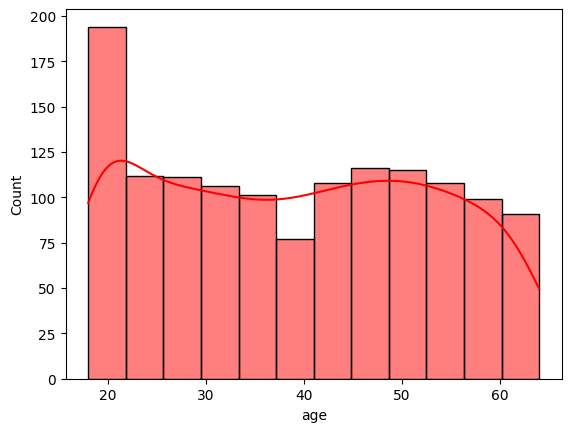

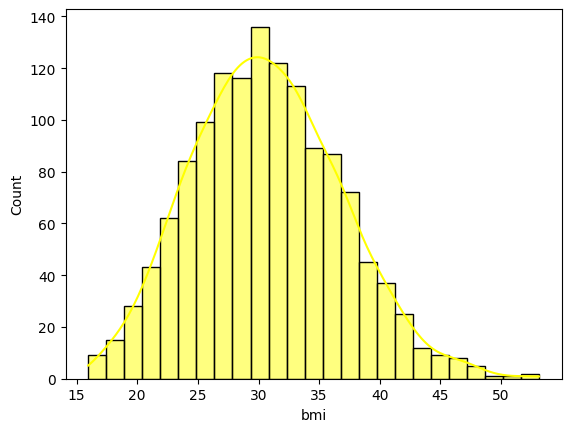

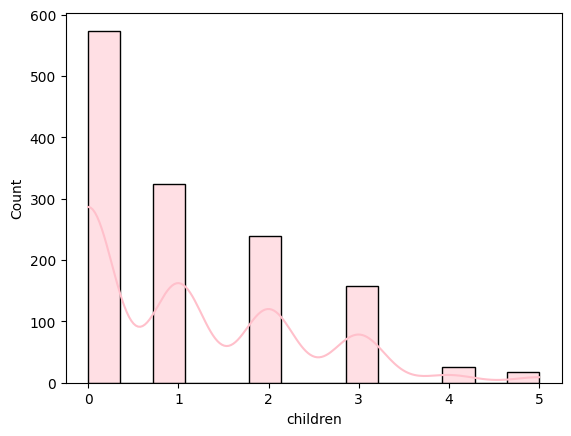

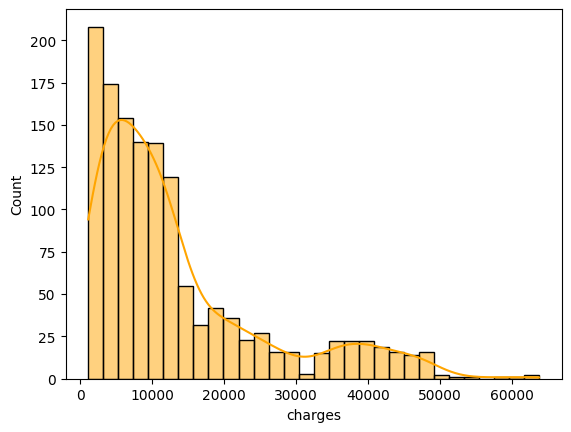

In [35]:
import seaborn as sb
import matplotlib.pyplot as plt

sb.histplot(df['age'],kde=True,color='red')
plt.show()
sb.histplot(df['bmi'],kde=True,color='yellow')
plt.show()
sb.histplot(df['children'],kde=True,color='pink')
plt.show()
sb.histplot(df['charges'],kde=True,color='orange')
plt.show()

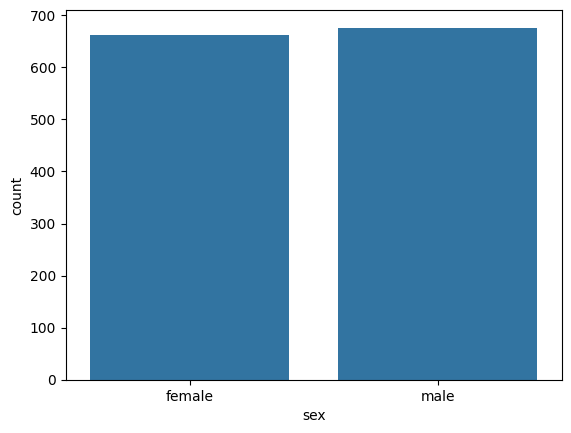

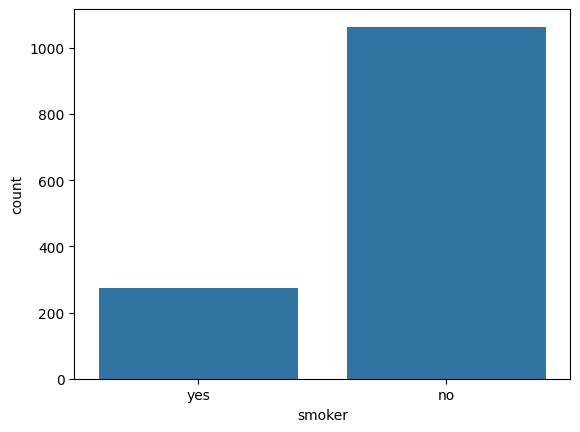

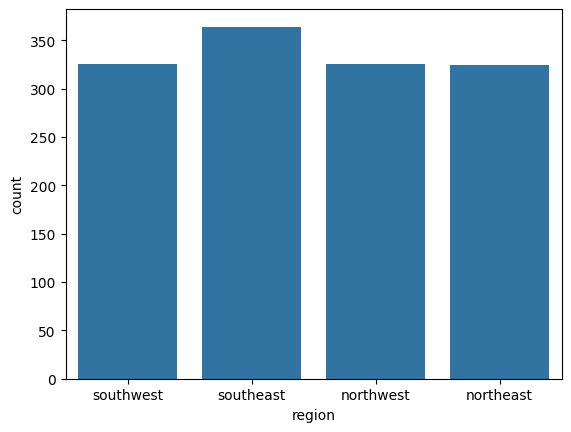

In [51]:
sb.countplot(df,x='sex')
plt.show()
sb.countplot(df,x='smoker')
plt.show()
sb.countplot(df,x='region')
plt.show()

**TASK 3:**
For visualisation of the total 7 columns i used the Seaborn library in order to analyse the distribution in values of each column. For numerical categories, I called the histplot in order to comprehense the distribution of the values.
In the first plot for the age, we notice a Uniform distribution with a slight peak at ages of 20 because from ages 18-20 the values are more frequent in the dataset. In the yellow one, which analyses the bmi, we can almost clearly see a normal distribution cause of symmetry and the most frequent values of it near to mean and median. As far as the pink plot is concerned, we can see a Discrete distribution because of Discrete values(0,1,2,3,4,5), right-skewed because of frequency of value 0. The orange plot which represents the charges can be considered as Right-Skewed because we can notice that most people have lower charges than 20.000 and in contrast, to the upper values, the distribution follows Uniform with a outlier to 30.000 which shows that mean is significantly higher than the median(13270 >9382).
For categorical/object columns, I approached the Seaborn library differently calling the countplot 3 times for the 3 categorical columns(sex,smoker,region).
As we notice, men and women dont vary very much as sample size. In contrast, we can see a significant difference between smokers and non-smokers because non-smokers outnumber smokers.The majority of the samples represent people with non-smoking habits. In the end, as for the region column, the largest portion of samples represent the Southeast. On the contrary,the other 3 regions have approximately equal sample size among them.

In [56]:
df.sample()

,age,sex,bmi,children,smoker,region,charges
274,25,male,27.55,0,no,northwest,2523.1695


**TASK 4:printing a random sample**

In [90]:
import numpy as np
import random

samples = np.random.randint(500,1100,size=5)
df['age'][samples].head()

random_bmis = np.random.randint(200,700,size=10)
df['bmi'][random_bmis].head()

,bmi
294,26.800
660,46.530
323,40.945
585,28.270
250,17.290


**TASK4: Choosing a certain sample size between 2 random integers using 2 arrays with integers**

In [96]:
from scipy import stats

no_children = df[df['children']==0]['charges']
has_children = df[df['children']>0]['charges']

t_stats, p_value = stats.ttest_ind(no_children,has_children)
print("Mean to those who do not have children is:", no_children.mean())
print("Mean to those who have children is:", has_children.mean())

if p_value < 0.05:
    print("There is no null hypothesis because charges with having children or not are related!")
else:
    print("We cannot reject null hypothesis")

Mean to those who do not have children is: 12365.97560163589
Mean to those who have children is: 13949.941093481675
There is no null hypothesis because charges with having children or not are related!


TASK 4: Hypothesis texting.. In this script, I wanted to recognise if people without children have less charges than people with children because I noticed in 2 diagrams of TASK 3(columns: children,charges) right-skewed distribution. As a result of p_value(0.01), we end in conclusion that these 2 columns are strongly related.

In [97]:
df_encoded = pd.get_dummies(df,columns=['sex'])
df_encoded.head()

,age,bmi,children,smoker,region,charges,sex_female,sex_male
0,19,27.900,0,yes,southwest,16884.92400,True,False
1,18,33.770,1,no,southeast,1725.55230,False,True
2,28,33.000,3,no,southeast,4449.46200,False,True
3,33,22.705,0,no,northwest,21984.47061,False,True
4,32,28.880,0,no,northwest,3866.85520,False,True


**TASK 4: One-Hot encoding**: I used get_dummies of the pandas library in order to create 2 binary columns depending on values(male,female) of the gender(sex) column

**TASK 5**: In the question "What is the typical medical cost of a customer?", I would prefer the median than mean because in the diagram which shows the column 'charges', it follows right-skew distribution. This means that mean is more sensitive to outliers while median is independent of them. As we can see, median is almost on the top of the distribution which shows the amount of charges in the most samples while mean can be calculated using outliers too which may represent a non-real prediction.





In [100]:
smokers = df[df['smoker']=='yes']
non_smokers =df[df['smoker']=='no']

print(smokers['charges'].mean())
print(smokers['charges'].median())
print(non_smokers['charges'].mean())
print(non_smokers['charges'].median())

32050.23183153284
34456.348450000005
8434.268297856204
7345.4053


Dividing the dataset in 2 parts(smokers,non-smokers), we notice an antithesis between 2 dataframes. In smokers, while the smokers are in minority of the total sample size, we can see median > mean which shows that most smokers have high charges. In contrast, non-smokers have mean > median which shows that even they are much more, the cost/charges are low.

In [101]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

In [102]:
df_normalised = pd.get_dummies(df,columns=['sex','smoker','region'])

In [103]:
df_normalised.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False


In [109]:
X = df_normalised.drop('charges',axis=1)
Y = df_normalised['charges']

In [110]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=50)

In [111]:
model = DecisionTreeRegressor()
model.fit(X_train,Y_train)

y_pred = model.predict(X_test)


In [112]:
from sklearn.metrics import mean_squared_error, r2_score

In [113]:
print(mean_squared_error(Y_test,y_pred))
print(r2_score(Y_test,y_pred))

35938453.01103088
0.775793337318382


In [115]:
model2 = LinearRegression()
model2.fit(X_train,Y_train)
y_predd = model2.predict(X_test)



In [116]:
print(mean_squared_error(Y_test,y_predd))
print(r2_score(Y_test,y_predd))

34742386.89805869
0.7832551496410703


By One-Hot encoding the data(categorical columns), dividing the dataset columns into features and label and after train/test split, developed DT and LR. With low differences in both mean_squared_error and r2_score, Linear Regression is preferred for this model because it has lower MSE which means that the predictions are closer to actual values and higher R2 score which represents better fit to data.